In [1]:
import os

# --- JAX / CUDA GPU MEMORY MANAGEMENT CONFIGURATION ---
# MUST be set at the very top of the notebook BEFORE 'import jax' or 'import flax'!
# 1. Disable JAX's default 75% GPU memory pre-allocation.
#    By default, JAX claims 75% of total GPU VRAM upfront upon initialization.
#    Setting this to "false" forces JAX to allocate GPU memory dynamically as needed,
#    preventing Out-Of-Memory (OOM) errors when sharing GPUs or running large intermediate graphs.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.9"
# 2. Use the CUDA Async Memory Allocator for XLA.
#    Replaces XLA's default rigid BFC (Best-Fit with Coalscing) allocator with CUDA's native 
#    async pool allocator. This reduces memory fragmentation during large intermediate tensor 
#    transformations (e.g. high-resolution L=1500 spherical convolutions/FFTs).
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

print("--- Environment Variables inside Container ---")
print("CUDA_VISIBLE_DEVICES  :", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("NVIDIA_VISIBLE_DEVICES:", os.environ.get("NVIDIA_VISIBLE_DEVICES"))

print("\n--- Testing nvidia-smi ---")
os.system("nvidia-smi")

import socket

print("=== VS CODE CONTAINER DIAGNOSTIC ===")
print("1. Hostname               :", socket.gethostname())
print("2. Slurm Job ID           :", os.environ.get("SLURM_JOB_ID", "NONE (Running outside Slurm!)"))
print("3. CUDA_VISIBLE_DEVICES   :", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("4. Apptainer GPU Devices  :", [f for f in os.listdir('/dev') if 'nvidia' in f] if os.path.exists('/dev') else "No /dev")

import sys

print("1. Python Binary  :", sys.executable)
print("2. Site-Packages  :", [p for p in sys.path if ".venv" in p])
print("3. CUDA Available :")

import torch
print("torch", torch.__version__, torch.cuda.is_available(), f"({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else "")

import jax
jax.config.update("jax_enable_x64", True)
print("Jax version", jax.__version__, "64-bit", jax.config.read("jax_enable_x64"))
print("jax", jax.__version__, "GPU backend:", jax.default_backend() == 'gpu', f"({jax.devices('gpu')[0].device_kind})" if jax.default_backend() == 'gpu' else "")

--- Environment Variables inside Container ---
CUDA_VISIBLE_DEVICES  : 0,1,2,3
NVIDIA_VISIBLE_DEVICES: all

--- Testing nvidia-smi ---
Thu Aug 13 11:37:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GH200 120GB             On  |   00000009:01:00.0 Off |                    0 |
| N/A   31C    P0             97W /  900W |       6MiB /  97871MiB |      0%      Default |
|    

/opt/venv/lib/python3.13/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12070). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


torch 2.13.0+cu130 False 
Jax version 0.11.0 64-bit True


E0813 11:37:51.392958   36648 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


jax 0.11.0 GPU backend: True (NVIDIA GH200 120GB)


In [2]:
import os
# 1. Force JAX to see the GPU
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# 2. Keep CPU threads from crashing if it falls back
# os.environ["OMP_NUM_THREADS"] = "4"
# os.environ["MKL_NUM_THREADS"] = "4"
# os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"
# 3. Provide valid temporary directory for ptxas CUDA kernel compilation
os.environ["TMPDIR"] = "/tmp"
os.environ["TMP"] = "/tmp"
os.environ["TEMP"] = "/tmp"

import dataclasses
import numpy as np

import jax.numpy as jnp
import flax
print("Flax version", flax.__version__)
from flax import nnx
import optax
# from sbi_compression.methods.utils import universal_flax_nnx_shim
# universal_flax_nnx_shim()

from torch.utils.data import Dataset, DataLoader, random_split

from s2ai.blocks.core_blocks import DiscoConvBlock, AverageBlock
from typing import Any, List, Optional, Callable, Sequence, Tuple, Union
from jaxtyping import Array, Float, Int, PyTree # https://github.com/google/jaxtyping

from typing import Literal, Callable, Optional
from tqdm import tqdm
from math import prod



Flax version 0.12.7


In [3]:
class DiscoCNNBuild(nnx.Module):
    "Builds spherical convolutional network based on set of tuples defining the convolution block per layer."
    def __init__(
        self,
        input_shape: tuple[int, ...],
        output_dim: int,
        layer_dims: list,
        activation: Callable = nnx.leaky_relu,
        rngs: nnx.Rngs | None = None, 
        ):

        if rngs is None:
            rngs = nnx.Rngs(0)

        self.input_shape = tuple(input_shape)
        self.output_dim = output_dim
        self.layer_dims = tuple(tuple(x) if not isinstance(x, tuple) else x for x in layer_dims)
        if len(self.layer_dims) == 0:
            raise ValueError("At least one layer dimension must be specified in layer_dims.")
        self.activation = activation
        self.rngs = rngs
        self.layers = nnx.List()
        
        raise NotImplementedError

    def check_layer_dims(
        self,
        input_shape: tuple[int, ...],
        output_dim: int,
        layer_dims: list,
        ):
        
        raise NotImplementedError

    def _add_layer(
        self,
        layer_dim: tuple,
        prev_layer_dim: tuple | None,
        layers: nnx.List,
        ):

        raise NotImplementedError
    
    def __call__(self, x):
        if len(self.layers) > 1:
            for layer in self.layers[:-1]:
                x = layer(x)
                x = self.activation(x)
            x = self.layers[-1](x)
        elif len(self.layers) == 1:
            for layer in self.layers:
                x = layer(x)
        return x


In [4]:
# directory = "/Users/brian/Downloads/map_compression_samples_5_tomo_bins_flm_1500_batch_1"
# directory = "/scratch/u6pf/brianycc.u6pf/spherical_maps/map_compression_samples_5_tomo_bins_flm_1500_batch_1/"
# directory = "/projects/u6pf/brianycc/spherical_maps/5_tomo_bins_flm_750_batch_1_mwss/"
directory = "/projects/u6pf/brianycc/spherical_maps/5_tomo_bins_flm_750_all_mwss/"
# n_map = 1
t = np.load(directory+f'/map_{1}.npy')
print(t.shape)
p = np.load(directory+"/params.npy")
print(p.shape)

# m = []
# for i in range(n_map):
#     m_add = np.load(directory+f'/map_{i}.npy')
#     m.append(m_add)
#     if i % 50 == 0 :
#         print(m_add.shape)
#         print(len(m))
# m = np.asarray(m)
# m = m.reshape((-1, 1500, 2*1500-1, 5)) 

(751, 1500, 5)
(6000, 5)


In [5]:
import s2fft

class SphericalMapDataset(Dataset):
    def __init__(self, 
        directory, 
        n_maps, 
        param_filename = "params.npy",
        stats_filename="map_stats.npz",
        normalise_params = True,
        normalise_maps = True,):
        """
        Args:
            directory (str): Path to the folder containing map_{i}.npy.
            n_maps (int): Total number of map samples to load.
            param_filename (str): Name of the parameters numpy file.
        """
        self.directory = directory
        self.n_maps = n_maps
        self.normalise_maps = normalise_maps
        self.normalise_params = normalise_params

        # The parameters file is tiny, so it is safe to load entirely into RAM
        param_path = os.path.join(directory, param_filename)
        raw_params = np.load(param_path)
        assert self.n_maps <= len(raw_params), f"Requested {self.n_maps} maps, but params.npy only has {len(raw_params)} rows!"
        
        # --- 1. Parameter Standardization ---
        self.normalise_params = normalise_params
        if self.normalise_params:
            self.param_mean = np.mean(raw_params, axis=0, keepdims=True)
            self.param_std = np.std(raw_params, axis=0, keepdims=True) #+ 1e-8
            self.params = (raw_params - self.param_mean) / self.param_std
        else:
            self.params = raw_params
            # self.param_mean = np.zeros((1, raw_params.shape[1]))
            # self.param_std = np.ones((1, raw_params.shape[1]))

        # 2. Load Pre-computed Map Stats
        if self.normalise_maps:
            stats_path = os.path.join(directory, stats_filename)
            assert os.path.exists(stats_path), f"Stats file {stats_path} not found! Run compute_and_save_map_stats first."
            
            stats = np.load(stats_path)
            # Shape for broadcasting over (theta, phi, channels): (1, 1, channels)
            self.map_mean = stats["mean"].reshape(1, 1, -1)
            self.map_std = stats["std"].reshape(1, 1, -1) #+ 1e-8

    def __len__(self):
        return self.n_maps
    
    def __getitem__(self, idx):
        # Lazily load only ONE map to memory on demand
        map_path = os.path.join(self.directory, f"map_{idx}.npy")
        m = np.load(map_path)
        p = self.params[idx].astype(np.float32)
        # Standardize Map dynamically per channel
        if self.normalise_maps:
            m = (m - self.map_mean) / self.map_std
        return m, p


In [6]:
class RectilinearAverageBlock(nnx.Module):
    def __init__(self):
        pass  # No spherical weights needed anymore

    def __call__(self, x):
        # x shape: (batch, theta, phi, channels) -> e.g., (1, 751, 1500, 5)
        # Average over both spatial dimensions (theta and phi) while keeping batch and channels
        return jnp.mean(x, axis=(1, 2))

class In750_Out5_DiscoCNN(nnx.Module):
    """Disco convolutional network with spherical group normalisation."""

    def __init__(
        self,
        # modes: List[str] = dataclasses.field(
        #     default_factory=lambda: ["disco", "disco", "disco", "disco"]
        # ),
        modes: tuple[str] = ("disco", "disco", "disco", "disco"),
        rngs: nnx.Rngs = nnx.Rngs(0),
        verbose: bool = False,
        dropout: bool = True,
    ):
        self.verbose = verbose
        self.dropout = dropout

        # These could be nnx.vmapped/scanned for faster initialization
        self.disco_conv_block_0 = DiscoConvBlock(
            (1500, 750), (5, 5), 5, mode=modes[0], rngs=rngs
        )
        self.disco_conv_block_1 = DiscoConvBlock(
            (750, 250), (5, 10), 10, mode=modes[1], rngs=rngs
        )
        self.disco_conv_block_2 = DiscoConvBlock(
            (250, 50), (10, 40), 40, mode=modes[2], rngs=rngs
        )
        self.disco_conv_block_3 = DiscoConvBlock(
            (50, 10), (40, 80), 80, mode=modes[3], rngs=rngs
        )

        # self.average_block = AverageBlock(L_in=10)
        self.average_block = RectilinearAverageBlock()

        self.dropout_4 = nnx.Dropout(0.5, rngs=rngs)
        self.dense_4 = nnx.Linear(
            in_features=160,
            out_features=80,
            rngs=rngs,
        )
        self.activation_4 = nnx.gelu

        self.dropout_5 = nnx.Dropout(0.5, rngs=rngs)
        self.dense_5 = nnx.Linear(
            in_features=80,
            out_features=40,
            rngs=rngs,
        )
        self.activation_5 = nnx.gelu

        self.dropout_6 = nnx.Dropout(0.5, rngs=rngs)
        self.dense_6 = nnx.Linear(
                    in_features=40,
                    out_features=20,
                    rngs=rngs,
                )
        self.activation_6 = nnx.gelu

        self.dropout_7 = nnx.Dropout(0.5, rngs=rngs)
        self.dense_7 = nnx.Linear(
            in_features=20,
            out_features=5,
            rngs=rngs,
        )

    # @nnx.remat
    def __call__(self, x):
        # Spherical convolutional blocks (L's, channels, groups)
        # x = self.disco_conv_block_0(x)
        x = self.disco_conv_block_1(x)
        x = self.disco_conv_block_2(x)
        x = self.disco_conv_block_3(x)
        jax.debug.print("Past disco block.") if self.verbose else None
        # Convert to equivariant dense layer
        x = self.average_block(x)
        # Standard MLP classifier
        # x = self.dropout_4(x) if self.dropout else x
        # x = self.dense_4(x)
        # x = self.activation_4(x)
        x = self.dropout_5(x) if self.dropout else x
        x = self.dense_5(x)
        x = self.activation_5(x)
        x = self.dropout_6(x) if self.dropout else x
        x = self.dense_6(x)
        x = self.activation_6(x)
        x = self.dropout_7(x) if self.dropout else x
        x = self.dense_7(x)
        jax.debug.print("Past dense mlp.") if self.verbose else None
        return x


class s2_AE_Flow(nnx.Module):

    def __init__(self,
        encoder: nnx.Module,
        flow: nnx.Module,
        encoder_mode: Literal['context', 'features'],
        verbose: bool = False,
        ):
        self.encoder_mode = encoder_mode
        self.encoder = encoder
        self.encoder.verbose = verbose
        self.flow = flow
        self.verbose = verbose
    
    def __call__(self, x: Array, context: Array) -> Array:
        if self.encoder_mode == 'context':
            context_encoded = self.encoder(context)
            x = self.flow(x, context_encoded)
        elif self.encoder_mode == 'features':
            x_encoded = self.encoder(x)
            x = self.flow(x_encoded, context)
        jax.debug.print("Past flow.") if self.verbose else None
        return x
    
    def sample(self, num_samples: int, rng: Array, context: Array) -> Array:
        x = self.flow.sample(num_samples, rng, context)
        return x
        
    def encode(self, x: Array) -> Array:
        # assert x.shape[-len(self.input_shape):] == self.input_shape # Make sure the input shape matches the encoder, assume batch first
        x = self.encoder(x)
        return x
    
    def mode(self, mode: Literal['train_encoder', 'train_flow', 'train_all', 'eval']) -> None:
        if mode == 'train_encoder':
            self.encoder.train()
            self.flow.eval()
        elif mode == 'train_flow':
            self.encoder.dropout = False
            self.encoder.eval()
            self.flow.train()
        elif mode == 'train_all':
            self.encoder.train()
            self.flow.train()
        elif mode == 'eval':
            self.encoder.dropout = False
            self.encoder.eval()
            self.flow.eval()
    


In [7]:
# import jax.numpy as jnp
# from jax.tree_util import tree_flatten

# params_state = nnx.state(S2_VMIM, nnx.Param)
# # params_state = nnx.state(s2_CNN, nnx.Param)
# # Assuming `params` is your model's parameter dictionary/pytree
# flat_params, _ = tree_flatten(params_state)
# param_bytes = sum(p.size * p.dtype.itemsize for p in flat_params)

# print(f"Model Parameters: {param_bytes / 1e6:.2f} MB")
# # Gradients take up the exact same amount of space
# print(f"Gradients: {param_bytes / 1e6:.2f} MB")

In [9]:
# sharding to utilise all gpus
from jax.sharding import Mesh, PartitionSpec as P, NamedSharding
devices = jax.devices()
mesh = Mesh(devices, ('batch',))
sharding_data = NamedSharding(mesh, P('batch', None)) # For inputs
# sharding_replicated = NamedSharding(mesh, P(None))
# sharding_weights = NamedSharding(mesh, P('batch', None))

s2_CNN = In750_Out5_DiscoCNN()

from sbi_compression.methods.neural.flows import RQSplineFlow
import distrax

features_shape = (5,)
context_shape = (5,)
features_dim = prod(features_shape)
context_dim = prod(context_shape)
n_transforms = 3
n_bins = 8
range_min = -4
range_max = 4
bijector_type = distrax.RationalQuadraticSpline
conditioner_hidden_dims = ((64,64), (64,64))
activation = "gelu"
flow = RQSplineFlow(
    features_dim, 
    context_dim, 
    n_transforms=n_transforms, 
    hidden_dims=conditioner_hidden_dims, 
    activation=getattr(nnx, activation), 
    n_bins=n_bins, 
    range_min=range_min, 
    range_max=range_max, 
    bijector_type=bijector_type
    )
    
S2_VMIM = s2_AE_Flow(s2_CNN, flow, 'context', verbose=False)



In [ ]:
LEARNING_RATE = 2e-3
TRAIN_TEST_SPLIT = 0.8
BATCH_SIZE = 64
STEPS = 1000
PRINT_EVERY = 50
N = 6000
L = 750

# Loss function
# def mse_loss(model, x, y):
#     preds = model(x, y)
#     if preds.shape != y.shape:
#         raise ValueError(f"Output shpae of the model {preds.shape} does not match the shape of the labels {y.shape}")
#     return jnp.mean((preds-y) ** 2)
def nll_loss(model, x, context):
    loss = -jnp.mean(model(x, context))
    return loss

# Optimiser
optimiser = nnx.Optimizer(
    S2_VMIM, 
    optax.adamw(LEARNING_RATE),
    wrt=nnx.Param
)

@nnx.jit(static_argnames="loss_fn")
def train_step(model, optimizer: nnx.Optimizer, loss_fn, x_batch, context_batch):
    """Train for a single step."""
    loss_value, grads = nnx.value_and_grad(loss_fn)(model, x_batch, context_batch)
    # optimiser.update(model, grads)  # In-place updates.
    return loss_value, grads

@nnx.jit(static_argnames="loss_fn")
def eval_step(model, loss_fn, x, context):
    """Calculate loss on test data without updating parameters."""
    loss_value = loss_fn(model, x, context)
    return loss_value

def infinite_trainloader():
    while True:
        yield from train_loader

train_losses = []
test_losses = []
test_steps = []

dataset = SphericalMapDataset(
    # directory="/projects/u6pf/brianycc/spherical_maps/5_tomo_bins_flm_1500_batch_1_mwss/", 
    directory="/projects/u6pf/brianycc/spherical_maps/5_tomo_bins_flm_750_all_mwss/", 
    n_maps=N, 
    param_filename="params.npy",
    normalise_params=True,
    normalise_maps=True
    )
print('Map mean and std', dataset.map_mean, dataset.map_std, '\nParam mean and std', dataset.param_mean, dataset.param_std)
train_size = int(TRAIN_TEST_SPLIT * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, 
    num_workers=0, # Set num_workeds=0 when using jax sharding
    persistent_workers=False) # Set persistant_workers=Flase when using jax sharding
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True, 
    num_workers=0, # Set num_workeds=0 when using jax sharding
    persistent_workers=False) # Set persistant_workers=Flase when using jax sharding

# with mesh:
#     # Get the state trees
#     model_state = nnx.state(S2_VMIM, nnx.Param)
#     opt_state = nnx.state(optimiser, nnx.Param) # or full optimizer state
#     # Apply sharding constraints so weights aren't duplicated blindly
#     sharded_model_state = jax.tree.map(
#         lambda x: jax.lax.with_sharding_constraint(x, sharding_weights), 
#         model_state
#     )
#     # Push the constrained states back into the live model graph
#     nnx.update(S2_VMIM, sharded_model_state)

for step, (x_batch, p_batch) in tqdm(zip(range(STEPS), infinite_trainloader())):
    x_jax = jnp.asarray(x_batch.detach().numpy() if hasattr(x_batch, 'detach') else x_batch)
    p_jax = jnp.asarray(p_batch.detach().numpy() if hasattr(p_batch, 'detach') else p_batch)
    x_sharded = jax.device_put(x_jax, sharding_data)
    p_sharded = jax.device_put(p_jax, sharding_data)
    # S2_VMIM.mode('train_all')
    train_loss, grads = train_step(S2_VMIM, optimiser, nll_loss, p_sharded, x_sharded) # Posteriior Estimation
    optimiser.update(S2_VMIM, grads)
    # Block until GPU finishes step (prevents asynchronous memory buildup)
    # train_loss.block_until_ready()
    train_losses.append(float(train_loss))
    # Explicitly delete batch references so Python garbage collector frees host RAM
    del x_batch, p_batch, x_jax, p_jax, x_sharded, p_sharded
    # --- EVALUATION PHASE ---
    if step % PRINT_EVERY == 0:
        # metrics.reset() # Clear training metrics to track test metrics
        # S2_VMIM.mode('eval')
        test_loss = 0
        for batch_x, batch_p in test_loader:
            jax_x = jnp.asarray(batch_x.detach().numpy() if hasattr(batch_x, 'detach') else batch_x)
            jax_p = jnp.asarray(batch_p.detach().numpy() if hasattr(batch_p, 'detach') else batch_p)
            sharded_x = jax.device_put(jax_x, sharding_data)
            sharded_p = jax.device_put(jax_p, sharding_data)
            test_loss += eval_step(S2_VMIM, nll_loss, sharded_p, sharded_x)
        test_loss /= len(test_loader)
        # test_loss.block_until_ready()
        test_losses.append(float(test_loss))
        del batch_x, batch_p, jax_x, jax_p, sharded_x, sharded_p
        test_steps.append(step)
        print(f"Step {step:3d} ({(step*BATCH_SIZE)/train_size:.1f} epoch) | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
print("Training completed.")


import pickle

# --- SAVING ---
# 1. Get the model state (parameters, batch stats, etc.)
state = nnx.state(S2_VMIM, nnx.Param)

# 2. Save it to a file
name = l = f's2VMIM_L{L}_{N}N_{STEPS}steps_{BATCH_SIZE}batch_{LEARNING_RATE}lr' + f'\n{n_transforms}transforms, {n_bins}bins'
os.makedirs('examples/checkpoints', exist_ok=True)
with open(f'examples/checkpoints/{name}.pkl', 'wb') as f:
    pickle.dump(state, f)
    print("Model saved at: ", f'\nexamples/checkpoints/{name}.pkl')



Map mean and std [[[0.00050942 0.00050919 0.00050897 0.00050895 0.00050911]]] [[[0.0081269  0.00812699 0.00812699 0.00812639 0.00812658]]] 
Param mean and std [[0.15249998 0.02249984 0.73       2.7599978  0.96999865]] [[0.0591732  0.00216505 0.05195844 0.66394578 0.07504407]]


1it [00:54, 54.88s/it]

Step   0 (0.0 epoch) | Train Loss: 7.832088 | Test Loss: 7.300878


51it [03:42, 13.89s/it]

Step  50 (0.7 epoch) | Train Loss: 6.665230 | Test Loss: 6.629558


...

Step 750 (10.0 epoch) | Train Loss: 4.907581 | Test Loss: 5.160379


801it [46:03, 15.05s/it]

Step 800 (10.7 epoch) | Train Loss: 5.024172 | Test Loss: 5.106653


838it [48:06,  2.72s/it]

: 

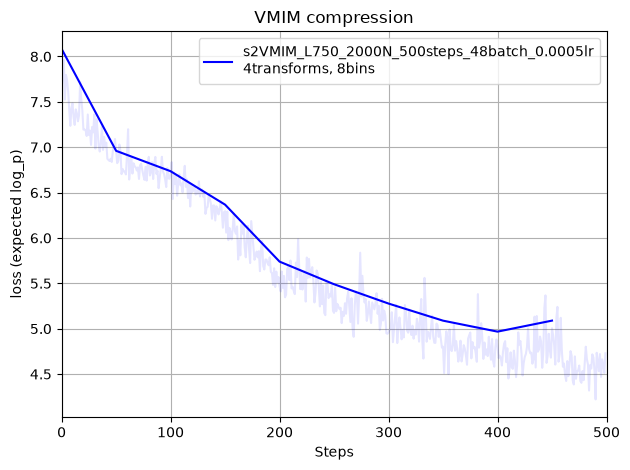

In [ ]:
import matplotlib.pyplot as plt

# Training loss time series
fig, ax = plt.subplots()
c = 'blue'
l = f's2VMIM_L{L}_{N}N_{STEPS}steps_{BATCH_SIZE}batch_{LEARNING_RATE}lr' + f'\n{n_transforms}transforms, {n_bins}bins'
# for r,l,c in zip(results_files,labels,colours):
#     with open("compressed_data/"+r, 'rb') as f:
        # load = pickle.load(f)
        # train_lossses = load["train_losses"]
        # test_losses = load["test_losses"]
        # test_steps = load["test_steps"]
ax.plot(range(STEPS), train_losses, color=c, alpha=0.1)
ax.plot(test_steps, test_losses, label=l, color=c)
ax.set_xlim(0,STEPS)
plt.grid()
plt.legend()
plt.xlabel("Steps")
plt.ylabel("loss (expected log_p)")
plt.title(f"VMIM compression")
plt.tight_layout()
plt.savefig(f"examples/plots/{l}.pdf")
plt.show()


In [11]:
import pickle

# --- LOADING ---
# 1. Create a fresh instance of the model with the SAME hyperparameters
s2_CNN = In750_Out5_DiscoCNN()

from sbi_compression.methods.neural.flows import RQSplineFlow
import distrax

features_shape = (5,)
context_shape = (5,)
features_dim = prod(features_shape)
context_dim = prod(context_shape)
n_transforms = 4
n_bins = 8
range_min = -4
range_max = 4
bijector_type = distrax.RationalQuadraticSpline
conditioner_hidden_dims = ((32,32), (32,32))
activation = "gelu"
flow = RQSplineFlow(
    features_dim, 
    context_dim, 
    n_transforms=n_transforms, 
    hidden_dims=conditioner_hidden_dims, 
    activation=getattr(nnx, activation), 
    n_bins=n_bins, 
    range_min=range_min, 
    range_max=range_max, 
    bijector_type=bijector_type
    )
    
load_model = s2_AE_Flow(s2_CNN, flow, 'context', verbose=False)

# 2. Load the state from the file
with open(f'examples/checkpoints/{name}.pkl', 'rb') as f:
    loaded_state = pickle.load(f)

# 3. Update the model with the loaded state
nnx.update(load_model, loaded_state)

Compressed data shape (1968, 5) 
Ground truth shape (1968, 5)


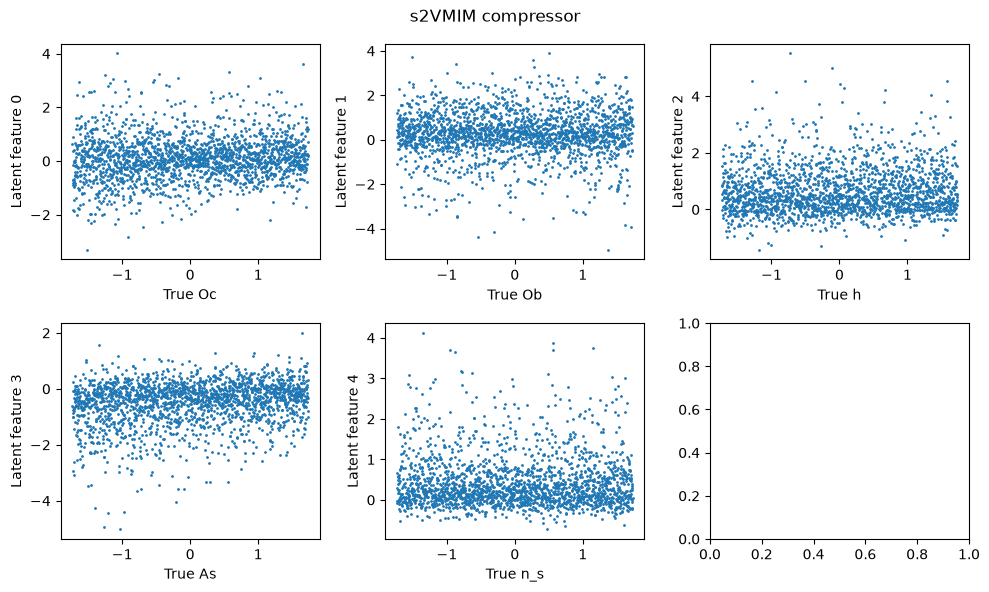

In [ ]:
directory="/projects/u6pf/brianycc/spherical_maps/5_tomo_bins_flm_750_all_mwss/"

gt = ground_truth = []
cd = compressed_data = []

dataset = SphericalMapDataset(
    # directory="/projects/u6pf/brianycc/spherical_maps/map_compression_samples_5_tomo_bins_flm_1500_batch_1/", 
    directory = directory, 
    n_maps = N, 
    param_filename = "params.npy"
    )
eval_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=4)
for x_batch, p_batch in eval_loader:
    cd.append(load_model.encode(jnp.asarray(x_batch)))
    gt.append(jnp.asarray(p_batch))
cd = np.concatenate([np.array(d) for d in cd])
gt = np.concatenate([np.array(t) for t in gt])
print("Compressed data shape", cd.shape, "\nGround truth shape", gt.shape)

params = ['Oc','Ob','h','As','n_s']
num_params = gt.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()
for i in range(num_params):
    ax = axes[i]
    ax.scatter(gt[:,i], cd[:,i], s=1)
    ax.set_xlabel(f'True {params[i]}')
    ax.set_ylabel(f'Latent feature {i}')

plt.suptitle("s2VMIM compressor")
plt.tight_layout()
plt.savefig(f"examples/plots/s2VMIM_scatter_{step}steps.pdf")
plt.show()

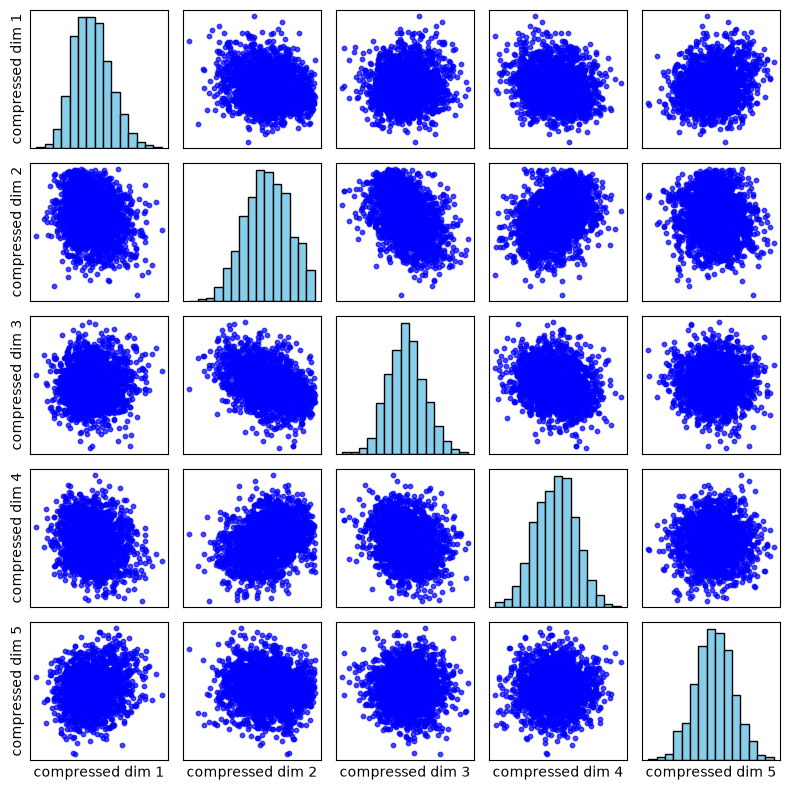

In [31]:
np.random.seed(42)
labels = [
    'compressed dim 1',
    'compressed dim 2',
    'compressed dim 3',
    'compressed dim 4',
    'compressed dim 5',
    ]

# Number of features
num_features = 5

# Create Subplots Grid
fig, axes = plt.subplots(num_features, num_features, figsize=(8, 8))

# Loop through each pair of features
for i in range(num_features):
    for j in range(num_features):
        ax = axes[i, j]
        
        if i == j:
            # Diagonal: Histogram of the feature
            ax.hist(cd[:, i], bins=15, color='skyblue', edgecolor='black')
        else:
            # Scatter plot for feature pairs
            ax.scatter(cd[:, j], cd[:, i], alpha=0.7, s=10, color="blue")

        # Set labels on the left and bottom axes
        if j == 0:
            ax.set_ylabel(labels[i], fontsize=10)
        if i == num_features - 1:
            ax.set_xlabel(labels[j], fontsize=10)

        # Remove ticks for a cleaner look
        ax.set_xticks([])
        ax.set_yticks([])

# Adjust layout
plt.tight_layout()
plt.show()